# dbt Model Generator

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-infra-toolkit/dbt-model-generator/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-infra-toolkit/dbt-model-generator/demo.ipynb)

> Auto-generate production-ready dbt staging models, source YAML, and schema tests from SQL CREATE TABLE statements.

**What this notebook covers:**
1. Parse SQL DDL into structured table metadata
2. Generate dbt source YAML configs
3. Generate staging model SQL with column renaming
4. Generate model schema YAML with tests
5. Visualize the generated file structure

## Step 1: Define the Core Parser

We parse SQL `CREATE TABLE` statements using regex to extract schema, table name, columns, types, nullability, and primary keys.

In [1]:
from __future__ import annotations

import re
from typing import Optional, List, Dict


def _split_columns(raw: str) -> List[str]:
    """Split column definitions by commas, ignoring commas inside parentheses."""
    parts = []
    depth = 0
    current = []
    for ch in raw:
        if ch == "(":
            depth += 1
            current.append(ch)
        elif ch == ")":
            depth -= 1
            current.append(ch)
        elif ch == "," and depth == 0:
            parts.append("".join(current))
            current = []
        else:
            current.append(ch)
    if current:
        parts.append("".join(current))
    return parts


def _extract_create_body(sql: str, start: int) -> Optional[str]:
    """Extract the parenthesized body of a CREATE TABLE, handling nested parens."""
    depth = 0
    for i in range(start, len(sql)):
        if sql[i] == "(":
            depth += 1
        elif sql[i] == ")":
            depth -= 1
            if depth == 0:
                return sql[start + 1 : i]
    return None


def parse_create_table(sql: str) -> List[Dict]:
    """Parse SQL CREATE TABLE statements into structured table metadata."""
    tables = []
    header_pattern = re.compile(
        r"CREATE\s+TABLE\s+(?:IF\s+NOT\s+EXISTS\s+)?"
        r"(?:(?P<schema>\w+)\.)?(?P<table>\w+)\s*\(",
        re.IGNORECASE,
    )

    for match in header_pattern.finditer(sql):
        schema = match.group("schema") or "public"
        table_name = match.group("table")
        paren_start = match.end() - 1
        columns_raw = _extract_create_body(sql, paren_start)
        if columns_raw is None:
            continue

        columns = []
        for line in _split_columns(columns_raw):
            line = line.strip()
            if not line:
                continue
            if re.match(r"^\s*(PRIMARY|FOREIGN|UNIQUE|CHECK|CONSTRAINT|INDEX)", line, re.IGNORECASE):
                continue

            parts = line.split()
            if len(parts) >= 2:
                col_name = parts[0].strip('"').strip("`").strip("[]")
                col_type = parts[1].upper()
                is_nullable = "NOT NULL" not in line.upper()
                is_pk = "PRIMARY KEY" in line.upper()
                columns.append({
                    "name": col_name,
                    "type": col_type,
                    "nullable": is_nullable,
                    "is_pk": is_pk,
                })

        tables.append({"schema": schema, "table": table_name, "columns": columns})

    return tables

## Step 2: Sample SQL Input

A typical e-commerce schema with customers, orders, and order items — the kind of DDL you'd paste from your warehouse.

In [2]:
SAMPLE_SQL = """
CREATE TABLE raw.customers (
    customer_id INTEGER PRIMARY KEY,
    firstName VARCHAR(100) NOT NULL,
    lastName VARCHAR(100) NOT NULL,
    email VARCHAR(255),
    signup_date TIMESTAMP NOT NULL,
    is_active BOOLEAN DEFAULT true,
    lifetime_value DECIMAL(10,2)
);

CREATE TABLE raw.orders (
    order_id INTEGER PRIMARY KEY,
    customer_id INTEGER NOT NULL,
    order_date TIMESTAMP NOT NULL,
    total_amount DECIMAL(10,2) NOT NULL,
    status VARCHAR(50) NOT NULL,
    shipping_address TEXT,
    FOREIGN KEY (customer_id) REFERENCES raw.customers(customer_id)
);

CREATE TABLE raw.order_items (
    item_id INTEGER PRIMARY KEY,
    order_id INTEGER NOT NULL,
    product_id INTEGER NOT NULL,
    quantity INTEGER NOT NULL,
    unit_price DECIMAL(10,2) NOT NULL,
    discount_pct FLOAT DEFAULT 0,
    FOREIGN KEY (order_id) REFERENCES raw.orders(order_id)
);
"""

tables = parse_create_table(SAMPLE_SQL)
for t in tables:
    print(f"Table: {t['schema']}.{t['table']} ({len(t['columns'])} columns)")
    for col in t["columns"]:
        pk = " [PK]" if col["is_pk"] else ""
        nn = " NOT NULL" if not col["nullable"] else ""
        print(f"  - {col['name']:20s} {col['type']:15s}{pk}{nn}")
    print()

Table: raw.customers (7 columns)
  - customer_id          INTEGER         [PK]
  - firstName            VARCHAR(100)    NOT NULL
  - lastName             VARCHAR(100)    NOT NULL
  - email                VARCHAR(255)   
  - signup_date          TIMESTAMP       NOT NULL
  - is_active            BOOLEAN        
  - lifetime_value       DECIMAL(10,2)  

Table: raw.orders (6 columns)
  - order_id             INTEGER         [PK]
  - customer_id          INTEGER         NOT NULL
  - order_date           TIMESTAMP       NOT NULL
  - total_amount         DECIMAL(10,2)   NOT NULL
  - status               VARCHAR(50)     NOT NULL
  - shipping_address     TEXT           

Table: raw.order_items (6 columns)
  - item_id              INTEGER         [PK]
  - order_id             INTEGER         NOT NULL
  - product_id           INTEGER         NOT NULL
  - quantity             INTEGER         NOT NULL
  - unit_price           DECIMAL(10,2)   NOT NULL
  - discount_pct         FLOAT          



## Step 3: Generate dbt Source YAML

Source configs tell dbt where raw data lives. We auto-generate `unique` and `not_null` tests on primary keys.

In [3]:
def generate_source_yaml(tables: List[Dict], source_name: str) -> str:
    lines = [
        "version: 2", "",
        "sources:",
        f"  - name: {source_name}",
        f'    description: "Auto-generated source for {source_name}"',
        "    tables:",
    ]
    for t in tables:
        lines.append(f"      - name: {t['table']}")
        lines.append(f'        description: "Source table {t["schema"]}.{t["table"]}"')
        lines.append("        columns:")
        for col in t["columns"]:
            lines.append(f"          - name: {col['name']}")
            lines.append(f'            description: ""')
            if col["is_pk"]:
                lines.extend(["            tests:", "              - unique", "              - not_null"])
            elif not col["nullable"]:
                lines.extend(["            tests:", "              - not_null"])
    return "\n".join(lines)


source_yaml = generate_source_yaml(tables, "raw_db")
print(source_yaml)

version: 2

sources:
  - name: raw_db
    description: "Auto-generated source for raw_db"
    tables:
      - name: customers
        description: "Source table raw.customers"
        columns:
          - name: customer_id
            description: ""
            tests:
              - unique
              - not_null
          - name: firstName
            description: ""
            tests:
              - not_null
          - name: lastName
            description: ""
            tests:
              - not_null
          - name: email
            description: ""
          - name: signup_date
            description: ""
            tests:
              - not_null
          - name: is_active
            description: ""
          - name: lifetime_value
            description: ""
      - name: orders
        description: "Source table raw.orders"
        columns:
          - name: order_id
            description: ""
            tests:
              - unique
              - not_null
     

## Step 4: Generate Staging Model SQL

Staging models follow dbt best practices: CTE-based, with camelCase → snake_case renaming.

In [4]:
def map_sql_type_to_dbt(sql_type: str) -> str:
    sql_type = sql_type.upper()
    if sql_type in ("INT", "INTEGER", "BIGINT", "SMALLINT", "TINYINT"):
        return "integer"
    if sql_type in ("FLOAT", "DOUBLE", "DECIMAL", "NUMERIC", "REAL", "NUMBER"):
        return "float"
    if sql_type in ("BOOL", "BOOLEAN"):
        return "boolean"
    if sql_type in ("DATE",):
        return "date"
    if sql_type in ("TIMESTAMP", "TIMESTAMPTZ", "DATETIME", "TIMESTAMP_NTZ"):
        return "timestamp"
    return "string"


def generate_staging_model(table: Dict, source_name: str) -> str:
    table_name = table["table"]
    model_name = f"stg_{source_name}__{table_name}"
    lines = [
        f"-- {model_name}.sql",
        f"-- Staging model for {source_name}.{table_name}",
        "",
        "with source as (",
        "",
        f"    select * from {{{{ source('{source_name}', '{table_name}') }}}}",
        "",
        "),",
        "",
        "renamed as (",
        "",
        "    select",
    ]
    col_lines = []
    for col in table["columns"]:
        col_name = col["name"]
        clean_name = re.sub(r"([A-Z])", r"_\1", col_name).lower().strip("_")
        if clean_name != col_name.lower():
            col_lines.append(f"        {col_name} as {clean_name}")
        else:
            col_lines.append(f"        {col_name}")
    lines.append(",\n".join(col_lines))
    lines.extend(["", "    from source", "", ")", "", "select * from renamed"])
    return "\n".join(lines)


# Generate for all tables
for table in tables:
    model_sql = generate_staging_model(table, "raw_db")
    print(model_sql)
    print("\n" + "=" * 60 + "\n")

-- stg_raw_db__customers.sql
-- Staging model for raw_db.customers

with source as (

    select * from {{ source('raw_db', 'customers') }}

),

renamed as (

    select
        customer_id,
        firstName as first_name,
        lastName as last_name,
        email,
        signup_date,
        is_active,
        lifetime_value

    from source

)

select * from renamed


-- stg_raw_db__orders.sql
-- Staging model for raw_db.orders

with source as (

    select * from {{ source('raw_db', 'orders') }}

),

renamed as (

    select
        order_id,
        customer_id,
        order_date,
        total_amount,
        status,
        shipping_address

    from source

)

select * from renamed


-- stg_raw_db__order_items.sql
-- Staging model for raw_db.order_items

with source as (

    select * from {{ source('raw_db', 'order_items') }}

),

renamed as (

    select
        item_id,
        order_id,
        product_id,
        quantity,
        unit_price,
        discount_pct

   

## Step 5: Generate Model Schema YAML

Schema YAML adds column descriptions and tests to staging models — essential for data quality.

In [5]:
def generate_model_yaml(table: Dict, source_name: str) -> str:
    table_name = table["table"]
    model_name = f"stg_{source_name}__{table_name}"
    lines = [
        "version: 2", "",
        "models:",
        f"  - name: {model_name}",
        f'    description: "Staging model for {table_name}"',
        "    columns:",
    ]
    for col in table["columns"]:
        clean_name = re.sub(r"([A-Z])", r"_\1", col["name"]).lower().strip("_")
        lines.append(f"      - name: {clean_name}")
        lines.append(f'        description: ""')
        tests = []
        if col["is_pk"]:
            tests.extend(["unique", "not_null"])
        elif not col["nullable"]:
            tests.append("not_null")
        if tests:
            lines.append("        tests:")
            for test in tests:
                lines.append(f"          - {test}")
    return "\n".join(lines)


for table in tables:
    model_yaml = generate_model_yaml(table, "raw_db")
    print(model_yaml)
    print("\n" + "-" * 40 + "\n")

version: 2

models:
  - name: stg_raw_db__customers
    description: "Staging model for customers"
    columns:
      - name: customer_id
        description: ""
        tests:
          - unique
          - not_null
      - name: first_name
        description: ""
        tests:
          - not_null
      - name: last_name
        description: ""
        tests:
          - not_null
      - name: email
        description: ""
      - name: signup_date
        description: ""
        tests:
          - not_null
      - name: is_active
        description: ""
      - name: lifetime_value
        description: ""

----------------------------------------

version: 2

models:
  - name: stg_raw_db__orders
    description: "Staging model for orders"
    columns:
      - name: order_id
        description: ""
        tests:
          - unique
          - not_null
      - name: customer_id
        description: ""
        tests:
          - not_null
      - name: order_date
        description: 

## Step 6: Visualize the Generated File Structure

A quick overview of what gets created — this is the dbt project layout the generator produces.

/var/folders/zf/9y5vgz8x1_72sv6fq_wkfksr0000gr/T/ipykernel_98162/3846000320.py:52: UserWarning: Glyph 128193 (\N{FILE FOLDER}) missing from current font.
  plt.tight_layout()
/var/folders/zf/9y5vgz8x1_72sv6fq_wkfksr0000gr/T/ipykernel_98162/3846000320.py:52: UserWarning: Glyph 128196 (\N{PAGE FACING UP}) missing from current font.
  plt.tight_layout()
/var/folders/zf/9y5vgz8x1_72sv6fq_wkfksr0000gr/T/ipykernel_98162/3846000320.py:53: UserWarning: Glyph 128193 (\N{FILE FOLDER}) missing from current font.
  plt.savefig("dbt_generator_output.png", dpi=150, bbox_inches="tight")
/var/folders/zf/9y5vgz8x1_72sv6fq_wkfksr0000gr/T/ipykernel_98162/3846000320.py:53: UserWarning: Glyph 128196 (\N{PAGE FACING UP}) missing from current font.
  plt.savefig("dbt_generator_output.png", dpi=150, bbox_inches="tight")
/opt/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128193 (\N{FILE FOLDER}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/op

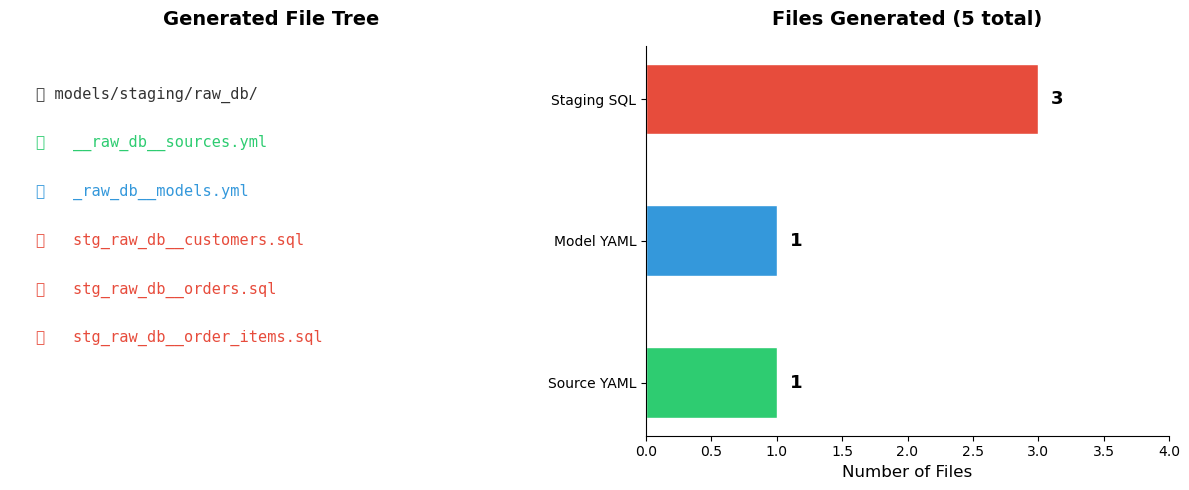


Total: 5 dbt files generated from 3 source tables


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

source_name = "raw_db"
table_names = [t["table"] for t in tables]

# Build file tree
files = [f"models/staging/{source_name}/"]
files.append(f"  __{source_name}__sources.yml")
files.append(f"  _{source_name}__models.yml")
for t in table_names:
    files.append(f"  stg_{source_name}__{t}.sql")

# Count by type
counts = {"Source YAML": 1, "Model YAML": 1, "Staging SQL": len(table_names)}
total = sum(counts.values())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: file tree
ax1 = axes[0]
ax1.set_xlim(0, 10)
ax1.set_ylim(-len(files) - 1, 1)
ax1.axis("off")
ax1.set_title("Generated File Tree", fontsize=14, fontweight="bold", pad=15)

colors_map = {"sources.yml": "#2ecc71", "models.yml": "#3498db", ".sql": "#e74c3c"}
for i, f in enumerate(files):
    color = "#333"
    for key, c in colors_map.items():
        if key in f:
            color = c
            break
    icon = "\U0001F4C1" if f.endswith("/") else "\U0001F4C4"
    ax1.text(0.5, -i, f"{icon} {f}", fontsize=11, fontfamily="monospace",
             color=color, verticalalignment="center")

# Right: bar chart of file counts
ax2 = axes[1]
categories = list(counts.keys())
values = list(counts.values())
bar_colors = ["#2ecc71", "#3498db", "#e74c3c"]
bars = ax2.barh(categories, values, color=bar_colors, height=0.5, edgecolor="white")
ax2.set_xlabel("Number of Files", fontsize=12)
ax2.set_title(f"Files Generated ({total} total)", fontsize=14, fontweight="bold", pad=15)
ax2.set_xlim(0, max(values) + 1)
for bar, val in zip(bars, values):
    ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
             str(val), va="center", fontsize=13, fontweight="bold")
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("dbt_generator_output.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nTotal: {total} dbt files generated from {len(tables)} source tables")

## Summary

From 3 `CREATE TABLE` statements, we generated:

| File Type | Count | Purpose |
|-----------|-------|---------|
| Source YAML | 1 | Declares raw data sources with tests |
| Model YAML | 1 | Schema tests for staging models |
| Staging SQL | 3 | CTE-based models with snake_case renaming |
| **Total** | **5** | **Production-ready dbt artifacts** |

Time saved: ~30-60 minutes of manual boilerplate per schema.

## Try Your Own

Paste your own SQL DDL below and re-run to generate dbt models for your schema.

In [7]:
# YOUR_SQL = """
# CREATE TABLE analytics.events (
#     event_id BIGINT PRIMARY KEY,
#     user_id INTEGER NOT NULL,
#     event_type VARCHAR(50) NOT NULL,
#     event_timestamp TIMESTAMP NOT NULL,
#     properties TEXT
# );
# """
#
# my_tables = parse_create_table(YOUR_SQL)
# for t in my_tables:
#     print(generate_staging_model(t, "my_source"))
#     print("---")
#     print(generate_model_yaml(t, "my_source"))

---

**[Back to Portfolio](https://github.com/phoebefu6/phoebe-the-builder)** | Run the full Streamlit app: `streamlit run app.py`